In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/renewable_forecasting_dataset.csv",
    parse_dates=["datetime"]
)

df.head()

,temperature_2m,relative_humidity_2m,pressure_msl,wind_speed_10m,wind_direction_10m,wind_gusts_10m,cloud_cover,shortwave_radiation,direct_radiation,sunshine_duration,country,datetime,solar_mwh,wind_onshore_mwh,wind_offshore_mwh,wind_total_mwh
0,2.2,95,1033.0,12.0,286,21.6,4,0.0,0.0,0.0,Germany,2020-01-01 00:00:00,0.0,5874.75,1169.25,7044.00
1,1.6,96,1033.3,11.4,283,19.8,2,0.0,0.0,0.0,Germany,2020-01-01 01:00:00,0.0,5764.75,1665.50,7430.25
2,2.1,94,1033.6,10.3,282,19.4,3,0.0,0.0,0.0,Germany,2020-01-01 02:00:00,0.0,5482.50,2062.25,7544.75
3,1.8,95,1033.3,11.2,270,18.7,12,0.0,0.0,0.0,Germany,2020-01-01 03:00:00,0.0,5457.00,2292.00,7749.00
4,1.2,96,1033.6,10.1,276,18.7,3,0.0,0.0,0.0,Germany,2020-01-01 04:00:00,0.0,5566.75,2159.50,7726.25


In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path


IMAGE_PATH = Path("../images")

IMAGE_PATH.mkdir(
    exist_ok=True
)

In [ ]:
df.shape



<class 'pandas.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   temperature_2m        52608 non-null  float64       
 1   relative_humidity_2m  52608 non-null  int64         
 2   pressure_msl          52608 non-null  float64       
 3   wind_speed_10m        52608 non-null  float64       
 4   wind_direction_10m    52608 non-null  int64         
 5   wind_gusts_10m        52608 non-null  float64       
 6   cloud_cover           52608 non-null  int64         
 7   shortwave_radiation   52608 non-null  float64       
 8   direct_radiation      52608 non-null  float64       
 9   sunshine_duration     52608 non-null  float64       
 10  country               52608 non-null  str           
 11  datetime              52608 non-null  datetime64[us]
 12  solar_mwh             52608 non-null  float64       
 13  wind_onshore_mwh      52608

temperature_2m          0
relative_humidity_2m    0
pressure_msl            0
wind_speed_10m          0
wind_direction_10m      0
wind_gusts_10m          0
cloud_cover             0
shortwave_radiation     0
direct_radiation        0
sunshine_duration       0
country                 0
datetime                0
solar_mwh               0
wind_onshore_mwh        0
wind_offshore_mwh       0
wind_total_mwh          0
dtype: int64

In [5]:
df["datetime"].min(), df["datetime"].max()

(Timestamp('2020-01-01 00:00:00'), Timestamp('2025-12-31 23:00:00'))

In [6]:
df["datetime"].diff().value_counts().head()

datetime
0 days 01:00:00    52607
Name: count, dtype: int64

In [7]:
###TOTAL PRODUCTION
df[
[
"solar_mwh",
"wind_total_mwh"
]
].describe()

,solar_mwh,wind_total_mwh
count,52608.000000,52608.000000
mean,6467.057906,14884.085235
std,10039.999798,10907.585370
min,0.000000,46.500000
25%,3.500000,5987.750000
50%,198.125000,12072.500000
75%,10217.187500,21810.562500
max,52132.250000,52875.500000


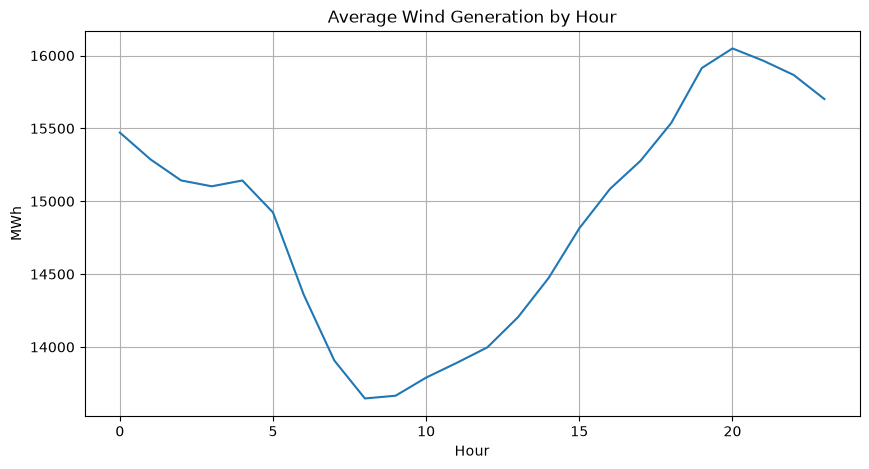

In [18]:
#### HOURLY PRODUCTION
df["hour"] = df["datetime"].dt.hour

hourly_wind = (
    df.groupby("hour")
    ["wind_total_mwh"]
    .mean()
)

plt.figure(figsize=(10,5))

hourly_wind.plot()

plt.title(
    "Average Wind Generation by Hour"
)

plt.xlabel("Hour")

plt.ylabel("MWh")

plt.grid()


plt.savefig(
    IMAGE_PATH / "wind_generation_hourly.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

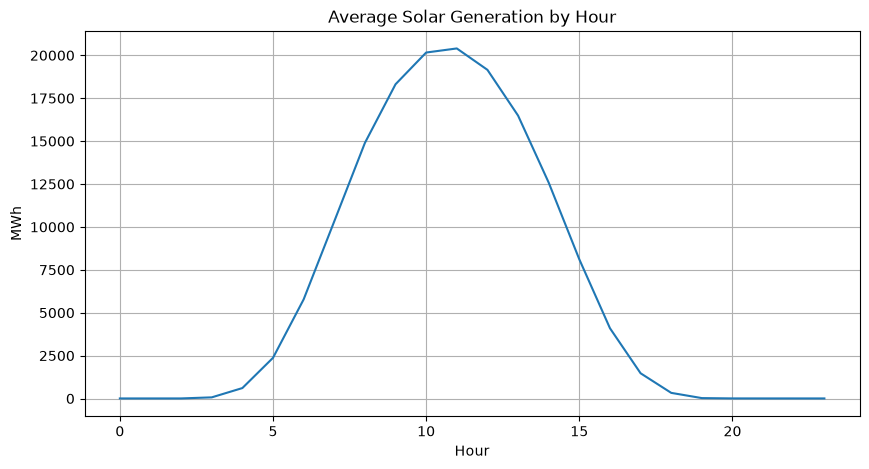

In [24]:
### Solar Generation Analysis
hourly_solar = (
    df.groupby("hour")
    ["solar_mwh"]
    .mean()
)

plt.figure(figsize=(10,5))

hourly_solar.plot()

plt.title(
    "Average Solar Generation by Hour"
)

plt.xlabel("Hour")

plt.ylabel("MWh")

plt.grid()


plt.savefig(
    IMAGE_PATH / "solar_generation_hourly.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
### Seasonality
df["month"] = df["datetime"].dt.month

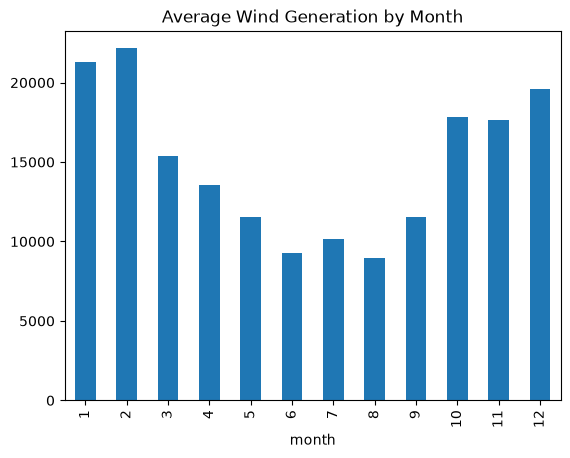

In [23]:
### WIND BY MONTH
(
df.groupby("month")
["wind_total_mwh"]
.mean()
.plot(
kind="bar",
title="Average Wind Generation by Month"
)

)

plt.savefig(
    IMAGE_PATH / "Average_Wind_Generation_by_Month.png",
    dpi=300,
    bbox_inches="tight")

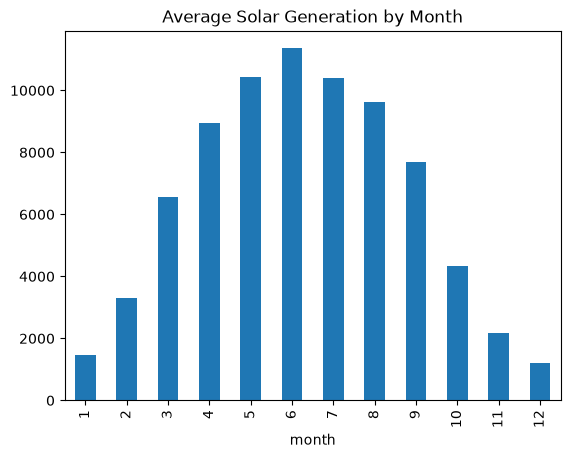

In [25]:
### SOLAR BY MONTH
(
df.groupby("month")
["solar_mwh"]
.mean()
.plot(
kind="bar",
title="Average Solar Generation by Month"
)
)

plt.savefig(
    IMAGE_PATH / "Average_Solar_Generation_by_Month.png",
    dpi=300,
    bbox_inches="tight")

In [13]:
### Wind speed correlation
df[
[
"wind_speed_10m",
"wind_total_mwh"
]
].corr()

,wind_speed_10m,wind_total_mwh
wind_speed_10m,1.000000,0.640562
wind_total_mwh,0.640562,1.000000


In [14]:
#### Solar radiation correlation
df[
[
"shortwave_radiation",
"solar_mwh"
]
].corr()

,shortwave_radiation,solar_mwh
shortwave_radiation,1.000000,0.669935
solar_mwh,0.669935,1.000000


In [15]:
#### HOURLY CHANGES
df["wind_change"] = (
df["wind_total_mwh"]
.diff()
)


df["solar_change"] = (
df["solar_mwh"]
.diff()
)

In [16]:
df[
[
"wind_change",
"solar_change"
]
].describe()

,wind_change,solar_change
count,52607.000000,52607.000000
mean,0.555863,0.000300
std,1163.421015,2934.665016
min,-7007.500000,-13055.750000
25%,-622.000000,-466.750000
50%,-24.500000,0.000000
75%,580.125000,307.125000
max,6983.250000,13367.680000


In [26]:
df["renewable_total_mwh"] = (
    df["wind_total_mwh"] +
    df["solar_mwh"]
)

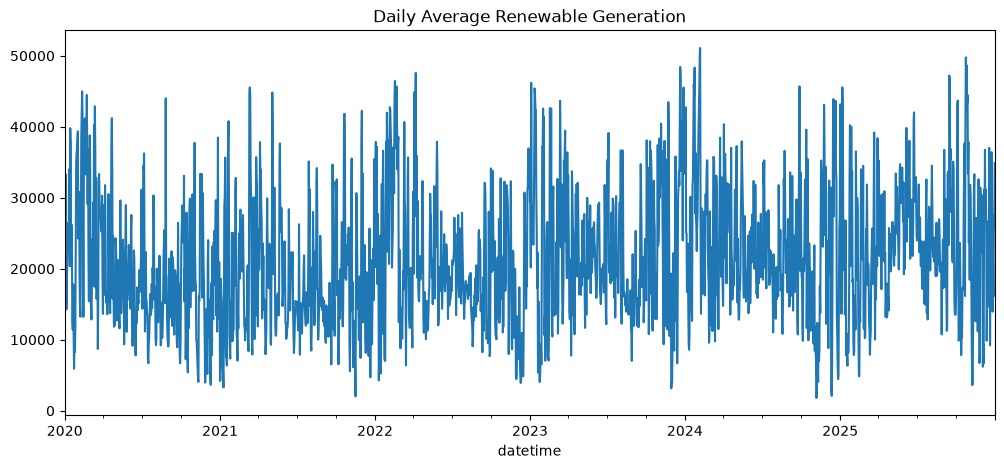

In [28]:
daily = (
    df
    .set_index("datetime")
    ["renewable_total_mwh"]
    .resample("D")
    .mean()
)


daily.plot(
    figsize=(12,5),
    title="Daily Average Renewable Generation"
)

plt.savefig(
    IMAGE_PATH / "Daily_Average_Renewable_Generation.png",
    dpi=300,
    bbox_inches="tight")

In [30]:
df["renewable_total_mwh"] = (
    df["solar_mwh"] +
    df["wind_total_mwh"]
)

df["renewable_change"] = (
    df["renewable_total_mwh"]
    .diff()
)


df["renewable_change"].describe()

count    52607.000000
mean         0.556163
std       2977.002715
min     -13329.540000
25%      -1140.620000
50%         -0.500000
75%       1281.250000
max      12419.220000
Name: renewable_change, dtype: float64

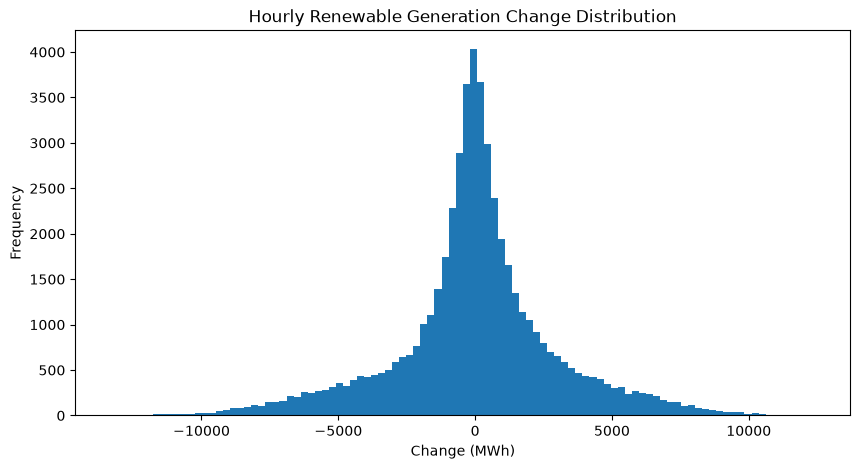

In [31]:
plt.figure(figsize=(10,5))

df["renewable_change"].hist(
    bins=100
)

plt.title(
    "Hourly Renewable Generation Change Distribution"
)

plt.xlabel(
    "Change (MWh)"
)

plt.ylabel(
    "Frequency"
)

plt.grid()

plt.savefig(
    "../images/renewable_ramp_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
large_ramps = df[
    abs(df["renewable_change"]) > 5000
]

len(large_ramps)

len(large_ramps) / len(df) * 100

11.581888686131386

Business Insights
Renewable Generation Forecasting Analysis — Germany
1. Renewable generation is highly weather dependent

The analysis confirms a strong relationship between meteorological variables and renewable energy production.

Solar generation shows a positive correlation with shortwave radiation:

Correlation: 0.67

Wind generation shows a positive correlation with wind speed:

Correlation: 0.64

This indicates that weather variables provide significant predictive information and should be included as key forecasting features.

2. Solar generation follows predictable daily and seasonal patterns

Photovoltaic generation demonstrates a strong dependency on:

hour of day
solar radiation
seasonal changes

Generation is close to zero during nighttime hours and reaches maximum values around midday.

This predictable behavior makes solar generation suitable for machine learning forecasting models.

3. Wind generation presents higher uncertainty

Wind production is strongly influenced by wind speed but shows more variability compared with solar generation.

The relationship is non-linear due to turbine operating characteristics:

low wind speeds produce limited generation
optimal wind speeds increase production rapidly
extreme wind conditions may reduce output due to turbine protection mechanisms

Therefore, non-linear machine learning models may provide better forecasting performance.

4. Renewable generation creates significant ramping challenges

The hourly renewable generation change analysis shows substantial variability:

Mean hourly change: approximately 0 MWh
Standard deviation: approximately 2,977 MWh
Maximum hourly increase: +12,419 MWh
Maximum hourly decrease: -13,330 MWh

Large generation ramps create operational challenges for grid balancing and electricity market management.

Accurate forecasting can help reduce uncertainty and improve system planning.

5. Forecasting value for energy operations

A reliable renewable forecasting system can support:

grid balancing decisions
renewable integration planning
energy trading strategies
reduction of imbalance costs
improved utilization of renewable assets

The EDA results justify the development of machine learning models for hourly renewable generation forecasting.

Key Takeaways
Area	Finding
Solar	Strong dependence on radiation and daily patterns
Wind	Strong weather dependency but higher uncertainty
Weather features	Important predictors for forecasting
Renewable ramps	Significant hourly variability exists
Business value	Better forecasting improves grid operations